---
Phase 6-1: 模型量化 — 讓模型更小更快
---

量化 = 把模型的數值精度降低
  FP32 (32 bit) → FP16 → INT8 (8 bit) → INT4 (4 bit)

為什麼要量化？
  1. 模型更小：INT8 比 FP32 小 4 倍
  2. 推論更快：整數運算比浮點快
  3. 省記憶體：7B 模型 FP32=28GB → INT4=3.5GB

本檔涵蓋：
  1. 量化的基本原理
  2. PTQ (Post-Training Quantization) — 訓練後量化
  3. QAT (Quantization-Aware Training) — 訓練中量化
  4. LLM 量化：GPTQ / AWQ / GGUF
  5. 動態量化 vs 靜態量化
  6. 實作：量化一個模型

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time

# ============================================================================
# 1. 量化的基本原理
# ============================================================================

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


1. 量化原理 — 從 FP32 到 INT8

浮點數 vs 整數：
  FP32: 32 bit, 範圍 ±3.4×10^38, 精度高
  FP16: 16 bit, 範圍 ±65504
  BF16: 16 bit, 範圍和 FP32 一樣, 但精度低
  INT8:  8 bit, 範圍 -128 ~ 127 (256 個值)
  INT4:  4 bit, 範圍 -8 ~ 7 (16 個值)

量化公式：
  量化:   q = round(x / scale) + zero_point
  反量化: x ≈ (q - zero_point) × scale

  scale = (x_max - x_min) / (q_max - q_min)
  zero_point = round(q_min - x_min / scale)

  例子 (對稱量化, INT8):
  x 的範圍: [-1.5, 1.5]
  scale = 3.0 / 254 ≈ 0.0118
  x = 0.5 → q = round(0.5 / 0.0118) = 42
  還原: 42 × 0.0118 = 0.496 (有一點誤差)

--- 不同精度的量化 ---

  INT8:
    Scale: 0.008289
    量化誤差 (MAE): 0.002186
    原始值: [0.9634576439857483, 0.7436420321464539, 0.4503585994243622, -1.0527604818344116]
    量化值: [116, 90, 54, -127]
    還原值: [0.961576521396637, 0.7460507154464722, 0.4476304352283478, -1.0527604818344116]

  INT4:
    Scale: 0.150394
    量化誤差 (MAE): 0.041295
    原始值: [0.9634576439857483, 0.7436420321464539, 0.4503585994243622, -1.0527604818344116]
    量化值: [6, 5, 3, -7]
    還原值: [0.9023661017417908

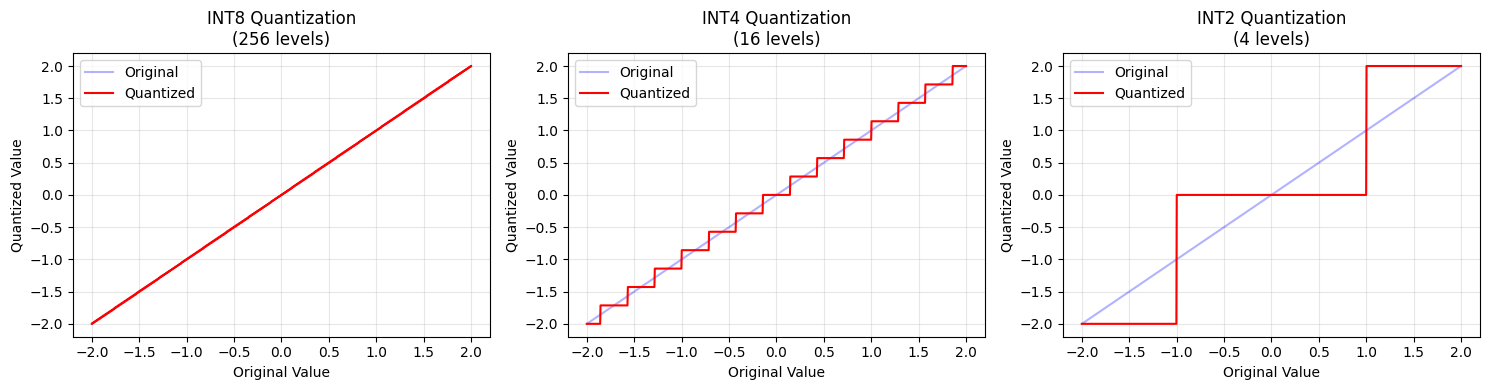


→ 圖表儲存至 plots/01_quantization_levels.png


In [2]:
print("=" * 60)
print("1. 量化原理 — 從 FP32 到 INT8")
print("=" * 60)

print("""
浮點數 vs 整數：
  FP32: 32 bit, 範圍 ±3.4×10^38, 精度高
  FP16: 16 bit, 範圍 ±65504
  BF16: 16 bit, 範圍和 FP32 一樣, 但精度低
  INT8:  8 bit, 範圍 -128 ~ 127 (256 個值)
  INT4:  4 bit, 範圍 -8 ~ 7 (16 個值)

量化公式：
  量化:   q = round(x / scale) + zero_point
  反量化: x ≈ (q - zero_point) × scale

  scale = (x_max - x_min) / (q_max - q_min)
  zero_point = round(q_min - x_min / scale)

  例子 (對稱量化, INT8):
  x 的範圍: [-1.5, 1.5]
  scale = 3.0 / 254 ≈ 0.0118
  x = 0.5 → q = round(0.5 / 0.0118) = 42
  還原: 42 × 0.0118 = 0.496 (有一點誤差)
""")


def quantize_tensor(tensor, n_bits=8, symmetric=True):
    """
    量化一個 tensor

    symmetric: 對稱量化 (zero_point=0, 更簡單)
    """
    if symmetric:
        # 對稱量化
        q_max = 2**(n_bits - 1) - 1   # 127 for INT8
        abs_max = tensor.abs().max()
        scale = abs_max / q_max
        quantized = torch.round(tensor / scale).clamp(-q_max - 1, q_max).to(torch.int8)
        return quantized, scale, 0
    else:
        # 非對稱量化
        q_min, q_max = -(2**(n_bits-1)), 2**(n_bits-1) - 1
        x_min, x_max = tensor.min(), tensor.max()
        scale = (x_max - x_min) / (q_max - q_min)
        zero_point = int(round(q_min - x_min / scale))
        quantized = torch.round(tensor / scale + zero_point).clamp(q_min, q_max).to(torch.int8)
        return quantized, scale, zero_point


def dequantize_tensor(quantized, scale, zero_point):
    """反量化"""
    return (quantized.float() - zero_point) * scale


# 展示量化效果
torch.manual_seed(42)
original = torch.randn(4, 4) * 0.5

print("--- 不同精度的量化 ---")
for n_bits in [8, 4, 2]:
    q, scale, zp = quantize_tensor(original, n_bits=n_bits)
    recovered = dequantize_tensor(q, scale, zp)
    error = (original - recovered).abs().mean()
    print(f"\n  INT{n_bits}:")
    print(f"    Scale: {scale:.6f}")
    print(f"    量化誤差 (MAE): {error:.6f}")
    print(f"    原始值: {original[0].tolist()}")
    print(f"    量化值: {q[0].tolist()}")
    print(f"    還原值: {recovered[0].tolist()}")

# 視覺化量化誤差
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, n_bits in enumerate([8, 4, 2]):
    values = torch.linspace(-2, 2, 1000)
    q_vals, scale, zp = quantize_tensor(values, n_bits=n_bits)
    recovered = dequantize_tensor(q_vals, scale, zp)

    axes[i].plot(values.numpy(), values.numpy(), 'b-', alpha=0.3, label='Original')
    axes[i].plot(values.numpy(), recovered.numpy(), 'r-', label='Quantized')
    axes[i].set_title(f'INT{n_bits} Quantization\n({2**n_bits} levels)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('Original Value')
    axes[i].set_ylabel('Quantized Value')

plt.tight_layout()
plt.savefig('phase-6-deployment/plots/01_quantization_levels.png', dpi=100)
plt.show()
print("\n→ 圖表儲存至 plots/01_quantization_levels.png")

## 2. 逐通道量化 vs 逐張量量化

In [3]:
print("\n" + "=" * 60)
print("2. 量化粒度")
print("=" * 60)

print("""
量化粒度（影響精度）：

  Per-Tensor (逐張量):
    整個權重矩陣用同一個 scale
    → 簡單但精度差

  Per-Channel (逐通道):
    每個輸出通道有自己的 scale
    → 更精確，最常用

  Per-Group (逐組):
    把通道再分成小組，每組一個 scale
    → GPTQ、AWQ 用的方法
    group_size=128: 每 128 個權重共用一個 scale

  粒度      精度    額外開銷    常用場景
  ─────────────────────────────────────
  Per-Tensor  低    最小       簡單場景
  Per-Channel 中    小         CNN 的標準做法
  Per-Group   高    中         LLM 量化
""")

# 展示差異
torch.manual_seed(42)
weight = torch.randn(4, 8) * torch.tensor([[0.1], [0.5], [2.0], [0.3]])
print(f"權重 shape: {weight.shape}")
print(f"每行的 range: {['[{:.2f}, {:.2f}]'.format(weight[i].min().item(), weight[i].max().item()) for i in range(4)]}")

# Per-tensor
q_pt, scale_pt, _ = quantize_tensor(weight, n_bits=8)
recovered_pt = dequantize_tensor(q_pt, scale_pt, 0)
error_pt = (weight - recovered_pt).abs().mean()

# Per-channel
errors_pc = []
for i in range(4):
    q_row, scale_row, _ = quantize_tensor(weight[i], n_bits=8)
    recovered_row = dequantize_tensor(q_row, scale_row, 0)
    errors_pc.append((weight[i] - recovered_row).abs().mean().item())
error_pc = np.mean(errors_pc)

print(f"\nPer-Tensor 量化誤差: {error_pt:.6f}")
print(f"Per-Channel 量化誤差: {error_pc:.6f}")
print(f"→ Per-Channel 精度更好（{error_pt/error_pc:.1f}x）")


2. 量化粒度

量化粒度（影響精度）：

  Per-Tensor (逐張量):
    整個權重矩陣用同一個 scale
    → 簡單但精度差

  Per-Channel (逐通道):
    每個輸出通道有自己的 scale
    → 更精確，最常用

  Per-Group (逐組):
    把通道再分成小組，每組一個 scale
    → GPTQ、AWQ 用的方法
    group_size=128: 每 128 個權重共用一個 scale

  粒度      精度    額外開銷    常用場景
  ─────────────────────────────────────
  Per-Tensor  低    最小       簡單場景
  Per-Channel 中    小         CNN 的標準做法
  Per-Group   高    中         LLM 量化

權重 shape: torch.Size([4, 8])
每行的 range: ['[-0.21, 0.19]', '[-0.70, 0.82]', '[-1.52, 3.36]', '[-0.08, 0.40]']

Per-Tensor 量化誤差: 0.007644
Per-Channel 量化誤差: 0.002126
→ Per-Channel 精度更好（3.6x）


## 3. PTQ — 訓練後量化

In [4]:
print("\n" + "=" * 60)
print("3. PTQ — Post-Training Quantization")
print("=" * 60)

print("""
PTQ: 模型訓練完之後才做量化
  優點: 不需要重新訓練
  缺點: 可能損失一些精度

PyTorch 的三種 PTQ 方式：

  1. 動態量化 (Dynamic Quantization):
     - 權重: 提前量化成 INT8
     - 激活值: 推論時動態量化
     - 最簡單，一行程式碼
     - 適合: Linear 層多的模型 (LSTM, Transformer)

  2. 靜態量化 (Static Quantization):
     - 權重和激活值都提前量化
     - 需要用校準資料跑一遍（確定激活值的範圍）
     - 更快，但需要額外步驟

  3. 量化 + 融合 (Quantization + Fusion):
     - 把 Conv+BN+ReLU 融合成一個算子
     - 進一步加速
""")

# 建立一個模型做量化實驗
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

digits = load_digits()
X = torch.tensor(digits.data, dtype=torch.float32)
y = torch.tensor(digits.target, dtype=torch.long)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.net(x)

# 訓練原始模型
torch.manual_seed(42)
model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

for epoch in range(30):
    model.train()
    for bx, by in loader:
        loss = criterion(model(bx), by)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    acc_fp32 = (model(X_te).argmax(1) == y_te).float().mean().item()
print(f"FP32 模型準確率: {acc_fp32:.2%}")

# 模型大小
import io
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
size_fp32 = buffer.tell()
print(f"FP32 模型大小: {size_fp32:,} bytes")

# 動態量化
quantized_model = torch.quantization.quantize_dynamic(
    model, {nn.Linear}, dtype=torch.qint8
)
with torch.no_grad():
    acc_int8 = (quantized_model(X_te).argmax(1) == y_te).float().mean().item()

buffer = io.BytesIO()
torch.save(quantized_model.state_dict(), buffer)
size_int8 = buffer.tell()

print(f"\nINT8 動態量化:")
print(f"  準確率: {acc_int8:.2%} (原始: {acc_fp32:.2%})")
print(f"  模型大小: {size_int8:,} bytes (壓縮比: {size_fp32/size_int8:.2f}x)")

# 速度比較
print("\n--- 速度比較 ---")
x_bench = torch.randn(100, 64)

start = time.time()
for _ in range(1000):
    _ = model(x_bench)
time_fp32 = time.time() - start

start = time.time()
for _ in range(1000):
    _ = quantized_model(x_bench)
time_int8 = time.time() - start

print(f"  FP32: {time_fp32:.3f}s (1000 次推論)")
print(f"  INT8: {time_int8:.3f}s (加速比: {time_fp32/time_int8:.2f}x)")


3. PTQ — Post-Training Quantization

PTQ: 模型訓練完之後才做量化
  優點: 不需要重新訓練
  缺點: 可能損失一些精度

PyTorch 的三種 PTQ 方式：

  1. 動態量化 (Dynamic Quantization):
     - 權重: 提前量化成 INT8
     - 激活值: 推論時動態量化
     - 最簡單，一行程式碼
     - 適合: Linear 層多的模型 (LSTM, Transformer)

  2. 靜態量化 (Static Quantization):
     - 權重和激活值都提前量化
     - 需要用校準資料跑一遍（確定激活值的範圍）
     - 更快，但需要額外步驟

  3. 量化 + 融合 (Quantization + Fusion):
     - 把 Conv+BN+ReLU 融合成一個算子
     - 進一步加速



FP32 模型準確率: 97.78%
FP32 模型大小: 71,637 bytes

INT8 動態量化:
  準確率: 97.78% (原始: 97.78%)
  模型大小: 22,591 bytes (壓縮比: 3.17x)

--- 速度比較 ---


/tmp/ipykernel_1759569/896423879.py:77: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


  FP32: 0.139s (1000 次推論)
  INT8: 0.367s (加速比: 0.38x)


## 4. 手動模擬量化推論

In [5]:
print("\n" + "=" * 60)
print("4. 手動模擬 INT8 推論")
print("=" * 60)

print("""
量化推論的流程：

  x (FP32) → 量化 → x_q (INT8)
  W (FP32) → 量化 → W_q (INT8)
  y_q = W_q @ x_q   (INT8 矩陣乘法，很快！)
  y = 反量化(y_q)    → (FP32)
""")

# 模擬量化的矩陣乘法
torch.manual_seed(42)
W = torch.randn(10, 64) * 0.1    # 模型權重
x = torch.randn(5, 64) * 0.5     # 輸入

# FP32 結果
y_fp32 = x @ W.T

# INT8 模擬
W_q, W_scale, _ = quantize_tensor(W, n_bits=8)
x_q, x_scale, _ = quantize_tensor(x, n_bits=8)

# INT8 矩陣乘法（用 float 模擬，實際硬體用整數）
y_q = x_q.float() @ W_q.float().T
y_int8 = y_q * (x_scale * W_scale)   # 反量化

error = (y_fp32 - y_int8).abs().mean()
relative_error = error / y_fp32.abs().mean()
print(f"FP32 結果:\n  {y_fp32[0, :5].tolist()}")
print(f"INT8 結果:\n  {y_int8[0, :5].tolist()}")
print(f"絕對誤差: {error:.6f}")
print(f"相對誤差: {relative_error:.4%}")


4. 手動模擬 INT8 推論

量化推論的流程：

  x (FP32) → 量化 → x_q (INT8)
  W (FP32) → 量化 → W_q (INT8)
  y_q = W_q @ x_q   (INT8 矩陣乘法，很快！)
  y = 反量化(y_q)    → (FP32)

FP32 結果:
  [-0.2561154067516327, 0.35554078221321106, -0.5745847225189209, 0.31268078088760376, -0.3810352683067322]
INT8 結果:
  [-0.25689977407455444, 0.350825697183609, -0.5641822218894958, 0.3173099160194397, -0.3821888267993927]
絕對誤差: 0.003186
相對誤差: 0.8346%


## 5. LLM 量化方法

In [6]:
print("\n" + "=" * 60)
print("5. LLM 量化 — GPTQ / AWQ / GGUF")
print("=" * 60)

print("""
LLM 太大了，量化是必須的：

  LLaMA-7B:
    FP32:  28 GB → 需要 A100
    FP16:  14 GB → 需要好的 GPU
    INT8:   7 GB → RTX 3090/4090
    INT4:  3.5 GB → RTX 3060/4060

  主要量化方法：

  ┌─────────────────────────────────────────────────┐
  │ GPTQ (2023):                                     │
  │   - 逐層量化，用 Hessian 資訊最小化量化誤差        │
  │   - 需要校準資料（128 條文字）                     │
  │   - INT4, per-group (group_size=128)             │
  │   - 工具: AutoGPTQ                               │
  │   - 精度很好，速度中等                             │
  └─────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────┐
  │ AWQ (Activation-Aware Quantization, 2023):       │
  │   - 保護「重要」的權重通道（對激活值影響大的）       │
  │   - 比 GPTQ 更快，精度相當                        │
  │   - 工具: AutoAWQ                                │
  │   - INT4, per-group                              │
  └─────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────┐
  │ GGUF (llama.cpp):                                │
  │   - 多種量化格式: Q4_0, Q4_K_M, Q5_K_M, Q8_0   │
  │   - 可以在 CPU 上跑！                            │
  │   - 和 llama.cpp / ollama 配合使用                │
  │   - 適合本地部署                                  │
  └─────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────┐
  │ bitsandbytes (HF/QLoRA):                         │
  │   - INT8 和 NF4 量化                             │
  │   - 和 Hugging Face transformers 深度整合         │
  │   - 主要用於 QLoRA 微調                           │
  └─────────────────────────────────────────────────┘

  用法範例（Hugging Face）：
  from transformers import AutoModelForCausalLM, BitsAndBytesConfig

  bnb_config = BitsAndBytesConfig(
      load_in_4bit=True,
      bnb_4bit_quant_type="nf4",
      bnb_4bit_compute_dtype=torch.float16,
  )
  model = AutoModelForCausalLM.from_pretrained(
      "meta-llama/Llama-2-7b-hf",
      quantization_config=bnb_config,
  )
""")


5. LLM 量化 — GPTQ / AWQ / GGUF

LLM 太大了，量化是必須的：

  LLaMA-7B:
    FP32:  28 GB → 需要 A100
    FP16:  14 GB → 需要好的 GPU
    INT8:   7 GB → RTX 3090/4090
    INT4:  3.5 GB → RTX 3060/4060

  主要量化方法：

  ┌─────────────────────────────────────────────────┐
  │ GPTQ (2023):                                     │
  │   - 逐層量化，用 Hessian 資訊最小化量化誤差        │
  │   - 需要校準資料（128 條文字）                     │
  │   - INT4, per-group (group_size=128)             │
  │   - 工具: AutoGPTQ                               │
  │   - 精度很好，速度中等                             │
  └─────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────┐
  │ AWQ (Activation-Aware Quantization, 2023):       │
  │   - 保護「重要」的權重通道（對激活值影響大的）       │
  │   - 比 GPTQ 更快，精度相當                        │
  │   - 工具: AutoAWQ                                │
  │   - INT4, per-group                              │
  └─────────────────────────────────────────────────┘

  ┌────────────────────────────────────

## 6. QAT — 訓練時感知量化

In [7]:
print("=" * 60)
print("6. QAT — Quantization-Aware Training")
print("=" * 60)

print("""
QAT: 在訓練過程中模擬量化的效果

  前向: x → fake_quantize(x) → 量化 → 反量化 → 繼續用 FP32 計算
  反向: 梯度穿過 fake_quantize (Straight-Through Estimator)

  效果：
  - 模型在訓練時就「習慣」了量化的精度損失
  - 比 PTQ 精度更好（特別是低 bit 量化）
  - 但需要重新訓練

  PyTorch QAT 流程：
  1. model.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')
  2. model_prepared = torch.quantization.prepare_qat(model)
  3. # 訓練 model_prepared
  4. model_int8 = torch.quantization.convert(model_prepared)
""")

# 模擬 Fake Quantization
def fake_quantize(x, n_bits=8):
    """模擬量化效果（前向用量化值，反向傳梯度）"""
    q_max = 2**(n_bits - 1) - 1
    scale = x.abs().max() / q_max
    q = torch.round(x / scale).clamp(-q_max - 1, q_max)
    # STE: 前向用量化值，反向傳原梯度
    return (q * scale - x).detach() + x

# 展示 STE
x = torch.tensor([0.3, 0.7, -0.5, 1.2], requires_grad=True)
y = fake_quantize(x, n_bits=4)
loss = y.sum()
loss.backward()
print(f"輸入: {x.data.tolist()}")
print(f"Fake Quantized: {y.data.tolist()}")
print(f"梯度 (STE): {x.grad.tolist()}")
print("→ 梯度 = 1（穿過量化層，好像它不存在一樣）")

6. QAT — Quantization-Aware Training

QAT: 在訓練過程中模擬量化的效果

  前向: x → fake_quantize(x) → 量化 → 反量化 → 繼續用 FP32 計算
  反向: 梯度穿過 fake_quantize (Straight-Through Estimator)

  效果：
  - 模型在訓練時就「習慣」了量化的精度損失
  - 比 PTQ 精度更好（特別是低 bit 量化）
  - 但需要重新訓練

  PyTorch QAT 流程：
  1. model.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')
  2. model_prepared = torch.quantization.prepare_qat(model)
  3. # 訓練 model_prepared
  4. model_int8 = torch.quantization.convert(model_prepared)

輸入: [0.30000001192092896, 0.699999988079071, -0.5, 1.2000000476837158]
Fake Quantized: [0.34285715222358704, 0.6857143044471741, -0.5142857432365417, 1.2000000476837158]
梯度 (STE): [1.0, 1.0, 1.0, 1.0]
→ 梯度 = 1（穿過量化層，好像它不存在一樣）


## 小結

In [8]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
模型量化完全指南：

  方法         精度    速度    適用場景
  ─────────────────────────────────────────
  FP32        最高    基準    訓練
  FP16/BF16   高     2x     訓練 + 推論
  INT8 PTQ    不錯    3-4x   推論部署
  INT8 QAT    好     3-4x   精度敏感的部署
  INT4 GPTQ   不錯    2-3x   LLM 推論
  INT4 AWQ    不錯    3-4x   LLM 推論
  GGUF        不錯    -      CPU 推論

  選擇指南：
    一般模型: PyTorch 動態量化（一行搞定）
    CNN 部署: INT8 靜態量化 + TensorRT
    LLM 推論: GPTQ/AWQ (GPU) 或 GGUF (CPU)
    LLM 微調: bitsandbytes NF4 + LoRA = QLoRA

  關鍵概念:
    量化 = round(x / scale) + zero_point
    Per-Channel > Per-Tensor（精度更好）
    INT4 用 group 量化保持精度
    QAT > PTQ（但需要重新訓練）

下一步：02_inference_acceleration.py — 推論加速
""")


小結

模型量化完全指南：

  方法         精度    速度    適用場景
  ─────────────────────────────────────────
  FP32        最高    基準    訓練
  FP16/BF16   高     2x     訓練 + 推論
  INT8 PTQ    不錯    3-4x   推論部署
  INT8 QAT    好     3-4x   精度敏感的部署
  INT4 GPTQ   不錯    2-3x   LLM 推論
  INT4 AWQ    不錯    3-4x   LLM 推論
  GGUF        不錯    -      CPU 推論

  選擇指南：
    一般模型: PyTorch 動態量化（一行搞定）
    CNN 部署: INT8 靜態量化 + TensorRT
    LLM 推論: GPTQ/AWQ (GPU) 或 GGUF (CPU)
    LLM 微調: bitsandbytes NF4 + LoRA = QLoRA

  關鍵概念:
    量化 = round(x / scale) + zero_point
    Per-Channel > Per-Tensor（精度更好）
    INT4 用 group 量化保持精度
    QAT > PTQ（但需要重新訓練）

下一步：02_inference_acceleration.py — 推論加速

